In [1]:
# Cell 1 - imports and paths

import pandas as pd
from pathlib import Path

METRICS_PATH = Path("/data/shared/fsibilla/clean_code/Q1/across_experiments_eval/metrics_all_experiments.csv")
EXPERIMENTS_BASE = Path("/data/shared/fsibilla/clean_code/Q1/experiments")

In [2]:
# Cell 2 - load metrics file

metrics_df = pd.read_csv(METRICS_PATH)
print(metrics_df.shape)
metrics_df.head()

(3575, 19)


,seed,adm1_code,adm1_name,target,n_true,n_gen,n_nat,n_over,emd_gen,emd_nat,emd_over,variability_intrinsic,absmeanerr_gen,absmeanerr_nat,absmeanerr_over,country,dataset,train_percent_int,experiment_id
0,1,Central,Central,vita_rae_mcg,2521,2521,77,2521,0.261724,0.175869,0.369485,0.113391,0.224365,0.718426,1.317057,lka,micron,1,lka_micron
1,1,Central,Central,folate_mcg,2521,2521,77,2521,0.464382,0.121110,0.279361,0.143093,2.690035,0.543052,0.090403,lka,micron,1,lka_micron
2,1,Central,Central,vitb12_mcg,2521,2521,77,2521,0.386113,0.327010,0.524923,0.439134,0.916129,0.785133,0.825319,lka,micron,1,lka_micron
3,1,Central,Central,fe_mg,2521,2521,77,2521,0.173448,0.231343,0.322648,0.263761,0.739603,1.094929,1.166151,lka,micron,1,lka_micron
4,1,Central,Central,zn_mg,2521,2521,77,2521,0.421575,0.375283,0.276471,0.170722,3.369188,3.102045,1.568397,lka,micron,1,lka_micron


In [3]:
context_cols_by_experiment = {
    "eth_micron": ["r3q_1", "rfh_avg_1", "vim_avg_1", "entropy_1", "rwi_1"],
    "lka_micron": ["r3q_1", "rfh_avg_1", "vim_avg_1", "entropy_1", "rwi_1"],
    "lka_vam": ["entropy_1", "rwi_1"],
    "moz_vam": ["entropy_1", "rwi_1"],
    "nga_micron": ["r3q_1", "rfh_avg_1", "vim_avg_1", "entropy_1", "rwi_1"],
    "nga_mics": ["entropy_1", "rwi_1"],
    "yem_mvam": ["entropy_2", "wscore_1"],
    "zwe_mics": ["entropy_1", "rwi_1"],
}

In [4]:
# Cell 4 - specify which column in full.csv identifies adm1
# Change this if in some experiments the adm1 column has a different name.

ADM1_COL_IN_FULL = "adm1name"   # e.g. "Central", "Eastern", "Tigray", etc.
ADM1_COL_IN_METRICS = "adm1_name"

In [5]:
# Cell 5 - choose how to aggregate context columns from full.csv to adm1 level
# Usually "mean" is the safest default for numeric context columns.

default_agg = "mean"

# Optional: override aggregation per column if you want
# Example:
# agg_overrides = {"some_binary_col": "mean", "some_id_like_col": "first"}
agg_overrides = {}

In [6]:
# Cell 6 - helper function to build adm1-level context table for one experiment

def build_adm1_context_table(
    experiment_id: str,
    context_cols: list[str],
    experiments_base: Path,
    adm1_col_in_full: str = "adm1name",
    default_agg: str = "mean",
    agg_overrides: dict | None = None,
) -> pd.DataFrame:
    """
    Read experiments/{experiment_id}/full.csv, keep adm1 + requested context columns,
    aggregate to one row per adm1, and return a dataframe ready for merging.
    """
    if agg_overrides is None:
        agg_overrides = {}

    full_path = experiments_base / experiment_id / "full.csv"
    if not full_path.exists():
        raise FileNotFoundError(f"full.csv not found for experiment_id={experiment_id}: {full_path}")

    full_df = pd.read_csv(full_path)

    missing = [c for c in [adm1_col_in_full, *context_cols] if c not in full_df.columns]
    if missing:
        raise KeyError(
            f"Missing columns in {full_path} for experiment_id={experiment_id}: {missing}"
        )

    use_cols = [adm1_col_in_full] + context_cols
    tmp = full_df[use_cols].copy()

    # Build aggregation dictionary
    agg_dict = {col: agg_overrides.get(col, default_agg) for col in context_cols}

    adm1_context = (
        tmp.groupby(adm1_col_in_full, dropna=False)
           .agg(agg_dict)
           .reset_index()
    )

    # Add experiment_id so merge is unambiguous across experiments
    adm1_context["experiment_id"] = experiment_id

    return adm1_context

In [7]:
# Cell 7 - build one combined context table for all experiments listed in context_cols_by_experiment

context_tables = []

for experiment_id, context_cols in context_cols_by_experiment.items():
    adm1_context_df = build_adm1_context_table(
        experiment_id=experiment_id,
        context_cols=context_cols,
        experiments_base=EXPERIMENTS_BASE,
        adm1_col_in_full=ADM1_COL_IN_FULL,
        default_agg=default_agg,
        agg_overrides=agg_overrides,
    )
    context_tables.append(adm1_context_df)

all_context_df = pd.concat(context_tables, ignore_index=True)
print(all_context_df.shape)
all_context_df.head()

(146, 9)


,adm1name,r3q_1,rfh_avg_1,vim_avg_1,entropy_1,rwi_1,experiment_id,entropy_2,wscore_1
0,Addis Ababa,99.701540,20.192404,0.415976,5.002233,0.997842,eth_micron,NaN,NaN
1,Afar,100.505583,6.763453,0.165411,0.482464,-0.493621,eth_micron,NaN,NaN
2,Amhara,107.455534,16.943017,0.378828,1.652131,-0.323604,eth_micron,NaN,NaN
3,B. Gumuz,103.748722,22.188618,0.569861,0.697333,-0.390573,eth_micron,NaN,NaN
4,Dire Dawa,92.982700,19.266650,0.280700,2.814014,-0.237109,eth_micron,NaN,NaN


In [8]:
# Cell 7b - extract actual target values per adm1+experiment from full.csv
# The target column name is taken from the "target" column in metrics_df

def build_adm1_target_table(
    experiment_id: str,
    target_names: list[str],
    experiments_base: Path,
    adm1_col_in_full: str = "adm1name",
) -> pd.DataFrame:
    """
    Read full.csv for an experiment, aggregate each target column to adm1 level,
    and return a long-format dataframe with columns: adm1name, experiment_id, target, target_value
    """
    full_path = experiments_base / experiment_id / "full.csv"
    full_df = pd.read_csv(full_path)

    records = []
    for target_name in target_names:
        if target_name not in full_df.columns:
            print(f"WARNING: target '{target_name}' not found in {full_path}, skipping.")
            continue
        agg = (
            full_df[[adm1_col_in_full, target_name]]
            .groupby(adm1_col_in_full, dropna=False)[target_name]
            .mean()
            .reset_index()
            .rename(columns={target_name: "target_value"})
        )
        agg["target"] = target_name
        agg["experiment_id"] = experiment_id
        records.append(agg)

    return pd.concat(records, ignore_index=True) if records else pd.DataFrame()


target_tables = []

for experiment_id in context_cols_by_experiment.keys():
    # get the target names that metrics_df actually uses for this experiment
    target_names = (
        metrics_df[metrics_df["experiment_id"] == experiment_id]["target"]
        .unique()
        .tolist()
    )
    target_df = build_adm1_target_table(
        experiment_id=experiment_id,
        target_names=target_names,
        experiments_base=EXPERIMENTS_BASE,
        adm1_col_in_full=ADM1_COL_IN_FULL,
    )
    target_tables.append(target_df)

all_targets_df = pd.concat(target_tables, ignore_index=True)
print(all_targets_df.shape)
all_targets_df.head()

(715, 4)


,adm1name,target_value,target,experiment_id
0,Addis Ababa,398.217953,va_ai,eth_micron
1,Afar,200.311741,va_ai,eth_micron
2,Amhara,227.629702,va_ai,eth_micron
3,B. Gumuz,312.660427,va_ai,eth_micron
4,Dire Dawa,331.062614,va_ai,eth_micron


In [9]:
# Cell 8 - merge context variables AND target values into the metrics dataframe

metrics_with_context = metrics_df.merge(
    all_context_df,
    left_on=["experiment_id", ADM1_COL_IN_METRICS],
    right_on=["experiment_id", ADM1_COL_IN_FULL],
    how="left",
)

if ADM1_COL_IN_FULL in metrics_with_context.columns and ADM1_COL_IN_FULL != ADM1_COL_IN_METRICS:
    metrics_with_context = metrics_with_context.drop(columns=[ADM1_COL_IN_FULL])

# merge target values — join on experiment_id + adm1 + target name
metrics_with_context = metrics_with_context.merge(
    all_targets_df,
    left_on=["experiment_id", ADM1_COL_IN_METRICS, "target"],
    right_on=["experiment_id", ADM1_COL_IN_FULL, "target"],
    how="left",
)

if ADM1_COL_IN_FULL in metrics_with_context.columns and ADM1_COL_IN_FULL != ADM1_COL_IN_METRICS:
    metrics_with_context = metrics_with_context.drop(columns=[ADM1_COL_IN_FULL])

print(metrics_with_context.shape)
metrics_with_context.head()

(3575, 27)


,seed,adm1_code,adm1_name,target,n_true,n_gen,n_nat,n_over,emd_gen,emd_nat,...,train_percent_int,experiment_id,r3q_1,rfh_avg_1,vim_avg_1,entropy_1,rwi_1,entropy_2,wscore_1,target_value
0,1,Central,Central,vita_rae_mcg,2521,2521,77,2521,0.261724,0.175869,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,215.800688
1,1,Central,Central,folate_mcg,2521,2521,77,2521,0.464382,0.121110,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,199.653885
2,1,Central,Central,vitb12_mcg,2521,2521,77,2521,0.386113,0.327010,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,0.963774
3,1,Central,Central,fe_mg,2521,2521,77,2521,0.173448,0.231343,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,11.801965
4,1,Central,Central,zn_mg,2521,2521,77,2521,0.421575,0.375283,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,8.582747


In [10]:
# Cell - collapse over seeds and keep improvement mean/std

# 1) row-level improvement
metrics_with_context["improvement"] = (
    metrics_with_context["emd_nat"] - metrics_with_context["emd_gen"]
)

# 2) choose grouping columns = everything that identifies a row EXCEPT seed
group_cols = [
    "adm1_code",
    "adm1_name",
    "target",
    "country",
    "dataset",
    "train_percent_int",
    "experiment_id",
]

# add context columns that exist in the dataframe
possible_context_cols = ["r3q", "rfh_avg", "vim_avg", "entropy_2", "rwi_1", "rwi_2"]
context_cols = [c for c in possible_context_cols if c in metrics_with_context.columns]

group_cols = group_cols + context_cols

# 3) aggregate over seeds
metrics_avg_over_seeds = (
    metrics_with_context
    .groupby(group_cols, dropna=False)
    .agg(
        n_true=("n_true", "mean"),
        n_gen=("n_gen", "mean"),
        n_nat=("n_nat", "mean"),
        n_over=("n_over", "mean"),
        emd_gen=("emd_gen", "mean"),
        emd_nat=("emd_nat", "mean"),
        emd_over=("emd_over", "mean"),
        variability_intrinsic=("variability_intrinsic", "mean"),
        absmeanerr_gen=("absmeanerr_gen", "mean"),
        absmeanerr_nat=("absmeanerr_nat", "mean"),
        absmeanerr_over=("absmeanerr_over", "mean"),
        improvement=("improvement", "mean"),
        improvement_std=("improvement", "std"),
        target_value=("target_value", "mean")
    )
    .reset_index()
)

# optional: if only one seed in a group, std is NaN -> replace with 0
metrics_avg_over_seeds["improvement_std"] = (
    metrics_avg_over_seeds["improvement_std"].fillna(0)
)

print(metrics_avg_over_seeds.shape)
metrics_avg_over_seeds.head()

(715, 23)


,adm1_code,adm1_name,target,country,dataset,train_percent_int,experiment_id,entropy_2,rwi_1,n_true,...,emd_gen,emd_nat,emd_over,variability_intrinsic,absmeanerr_gen,absmeanerr_nat,absmeanerr_over,improvement,improvement_std,target_value
0,Abia,Abia,avg_adult_education,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.155532,0.190426,0.430107,0.240679,0.461073,0.541277,1.053102,0.034895,0.065574,9.434649
1,Abia,Abia,avg_adult_education,nga,mics,1,nga_mics,NaN,0.253542,747.0,...,0.137299,0.267583,0.160896,0.272826,0.368154,0.735606,0.306277,0.130284,0.094455,0.513997
2,Abia,Abia,fe_ai,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.243059,0.277475,0.760750,0.262250,0.777744,0.917632,2.397793,0.034416,0.192878,17.253943
3,Abia,Abia,fol_ai,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.186035,0.140974,0.607941,0.115583,0.570675,0.418435,1.885481,-0.045061,0.134293,276.516567
4,Abia,Abia,log_exp,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.300576,0.164013,0.528138,0.150741,0.953515,0.272784,1.583671,-0.136564,0.137577,8.687822


In [11]:
metrics_avg_over_seeds.to_csv("/data/shared/fsibilla/clean_code/Q1/R2/metrics_with_context.csv", index=False)

## Fit R^2

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut
import numpy as np

LOG_PATH = "/data/shared/fsibilla/clean_code/Q1/R2/regression_log_rf_loo.txt"

regression_results = []
loo_predictions = []

with open(LOG_PATH, "w") as log:
    def log_print(*args, **kwargs):
        msg = " ".join(str(a) for a in args)
        print(msg, **kwargs)
        log.write(msg + "\n")
        log.flush()

    for experiment_id, context_cols in context_cols_by_experiment.items():
        exp_df = metrics_avg_over_seeds[metrics_avg_over_seeds["experiment_id"] == experiment_id].copy()

        context_cols_present = [c for c in context_cols if c in exp_df.columns]
        if not context_cols_present:
            log_print(f"SKIP {experiment_id}: no context columns found")
            continue

        for target_name in exp_df["target"].unique():
            target_df = exp_df[exp_df["target"] == target_name].copy()

            cols_needed = context_cols_present + ["target_value"]
            target_df = target_df.dropna(subset=cols_needed)
            target_df = target_df[np.isfinite(target_df[cols_needed]).all(axis=1)].reset_index(drop=True)

            if len(target_df) < len(context_cols_present) + 1:
                log_print(f"SKIP {experiment_id} / {target_name}: not enough rows ({len(target_df)})")
                continue

            X = target_df[context_cols_present].values
            y = target_df["target_value"].values

            loo = LeaveOneOut()
            y_true_loo, y_pred_loo, adm1_loo = [], [], []

            for train_idx, test_idx in loo.split(X):
                model = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
                model.fit(X[train_idx], y[train_idx])
                y_true_loo.append(y[test_idx[0]])
                y_pred_loo.append(model.predict(X[test_idx])[0])
                adm1_loo.append(target_df.loc[test_idx[0], "adm1_name"])

            y_true_loo = np.array(y_true_loo)
            y_pred_loo = np.array(y_pred_loo)

            r2  = r2_score(y_true_loo, y_pred_loo)
            # mean relative error: average of |y_true - y_pred| / |y_true|
            # mask zeros to avoid division by zero
            nonzero = y_true_loo != 0
            mre = np.mean(np.abs(y_true_loo[nonzero] - y_pred_loo[nonzero]) / np.abs(y_true_loo[nonzero]))

            log_print(f"{experiment_id} / {target_name}: R²={r2:.3f}  MRE={mre:.3f}  (n={len(target_df)})")

            regression_results.append({
                "experiment_id": experiment_id,
                "target": target_name,
                "r2": r2,
                "mre": mre,
                "n_adm1": len(target_df),
                "context_cols": context_cols_present,
            })

            for adm1, yt, yp in zip(adm1_loo, y_true_loo, y_pred_loo):
                rel_err = abs(yt - yp) / abs(yt) if yt != 0 else np.nan
                loo_predictions.append({
                    "experiment_id": experiment_id,
                    "target": target_name,
                    "adm1_name": adm1,
                    "y_true": yt,
                    "y_pred": yp,
                    "residual": yt - yp,
                    "relative_error": rel_err,
                })

    results_df = pd.DataFrame(regression_results)
    loo_pred_df = pd.DataFrame(loo_predictions)

    log_print("\n--- Summary ---")
    log_print(results_df[["experiment_id", "target", "r2", "mre", "n_adm1"]].to_string())
    log_print(f"\nLog saved to {LOG_PATH}")

eth_micron / avg_adult_education: R²=0.444  MRE=0.251  (n=11)
eth_micron / fe_ai: R²=0.076  MRE=0.272  (n=11)
eth_micron / fol_ai: R²=0.173  MRE=0.277  (n=11)
eth_micron / log_exp: R²=0.267  MRE=0.068  (n=11)
eth_micron / va_ai: R²=-0.127  MRE=0.354  (n=11)
eth_micron / vb12_ai: R²=0.346  MRE=0.248  (n=11)
eth_micron / zn_ai: R²=-0.015  MRE=0.218  (n=11)
lka_micron / avg_adult_education: R²=0.105  MRE=0.046  (n=9)
lka_micron / fe_mg: R²=-0.612  MRE=0.098  (n=9)
lka_micron / folate_mcg: R²=-0.759  MRE=0.091  (n=9)
lka_micron / log_exp: R²=0.200  MRE=0.019  (n=9)
lka_micron / vita_rae_mcg: R²=-0.422  MRE=0.122  (n=9)
lka_micron / vitb12_mcg: R²=-0.477  MRE=0.290  (n=9)
lka_micron / zn_mg: R²=-1.690  MRE=0.073  (n=9)
lka_vam / FCS: R²=0.344  MRE=0.039  (n=9)
lka_vam / FES: R²=-1.521  MRE=0.056  (n=9)
lka_vam / education_score: R²=-0.816  MRE=0.049  (n=9)
lka_vam / log_income: R²=-0.131  MRE=0.009  (n=9)
lka_vam / rCSI: R²=-0.055  MRE=0.155  (n=9)
lka_vam / space_per_person: R²=0.036  MRE=

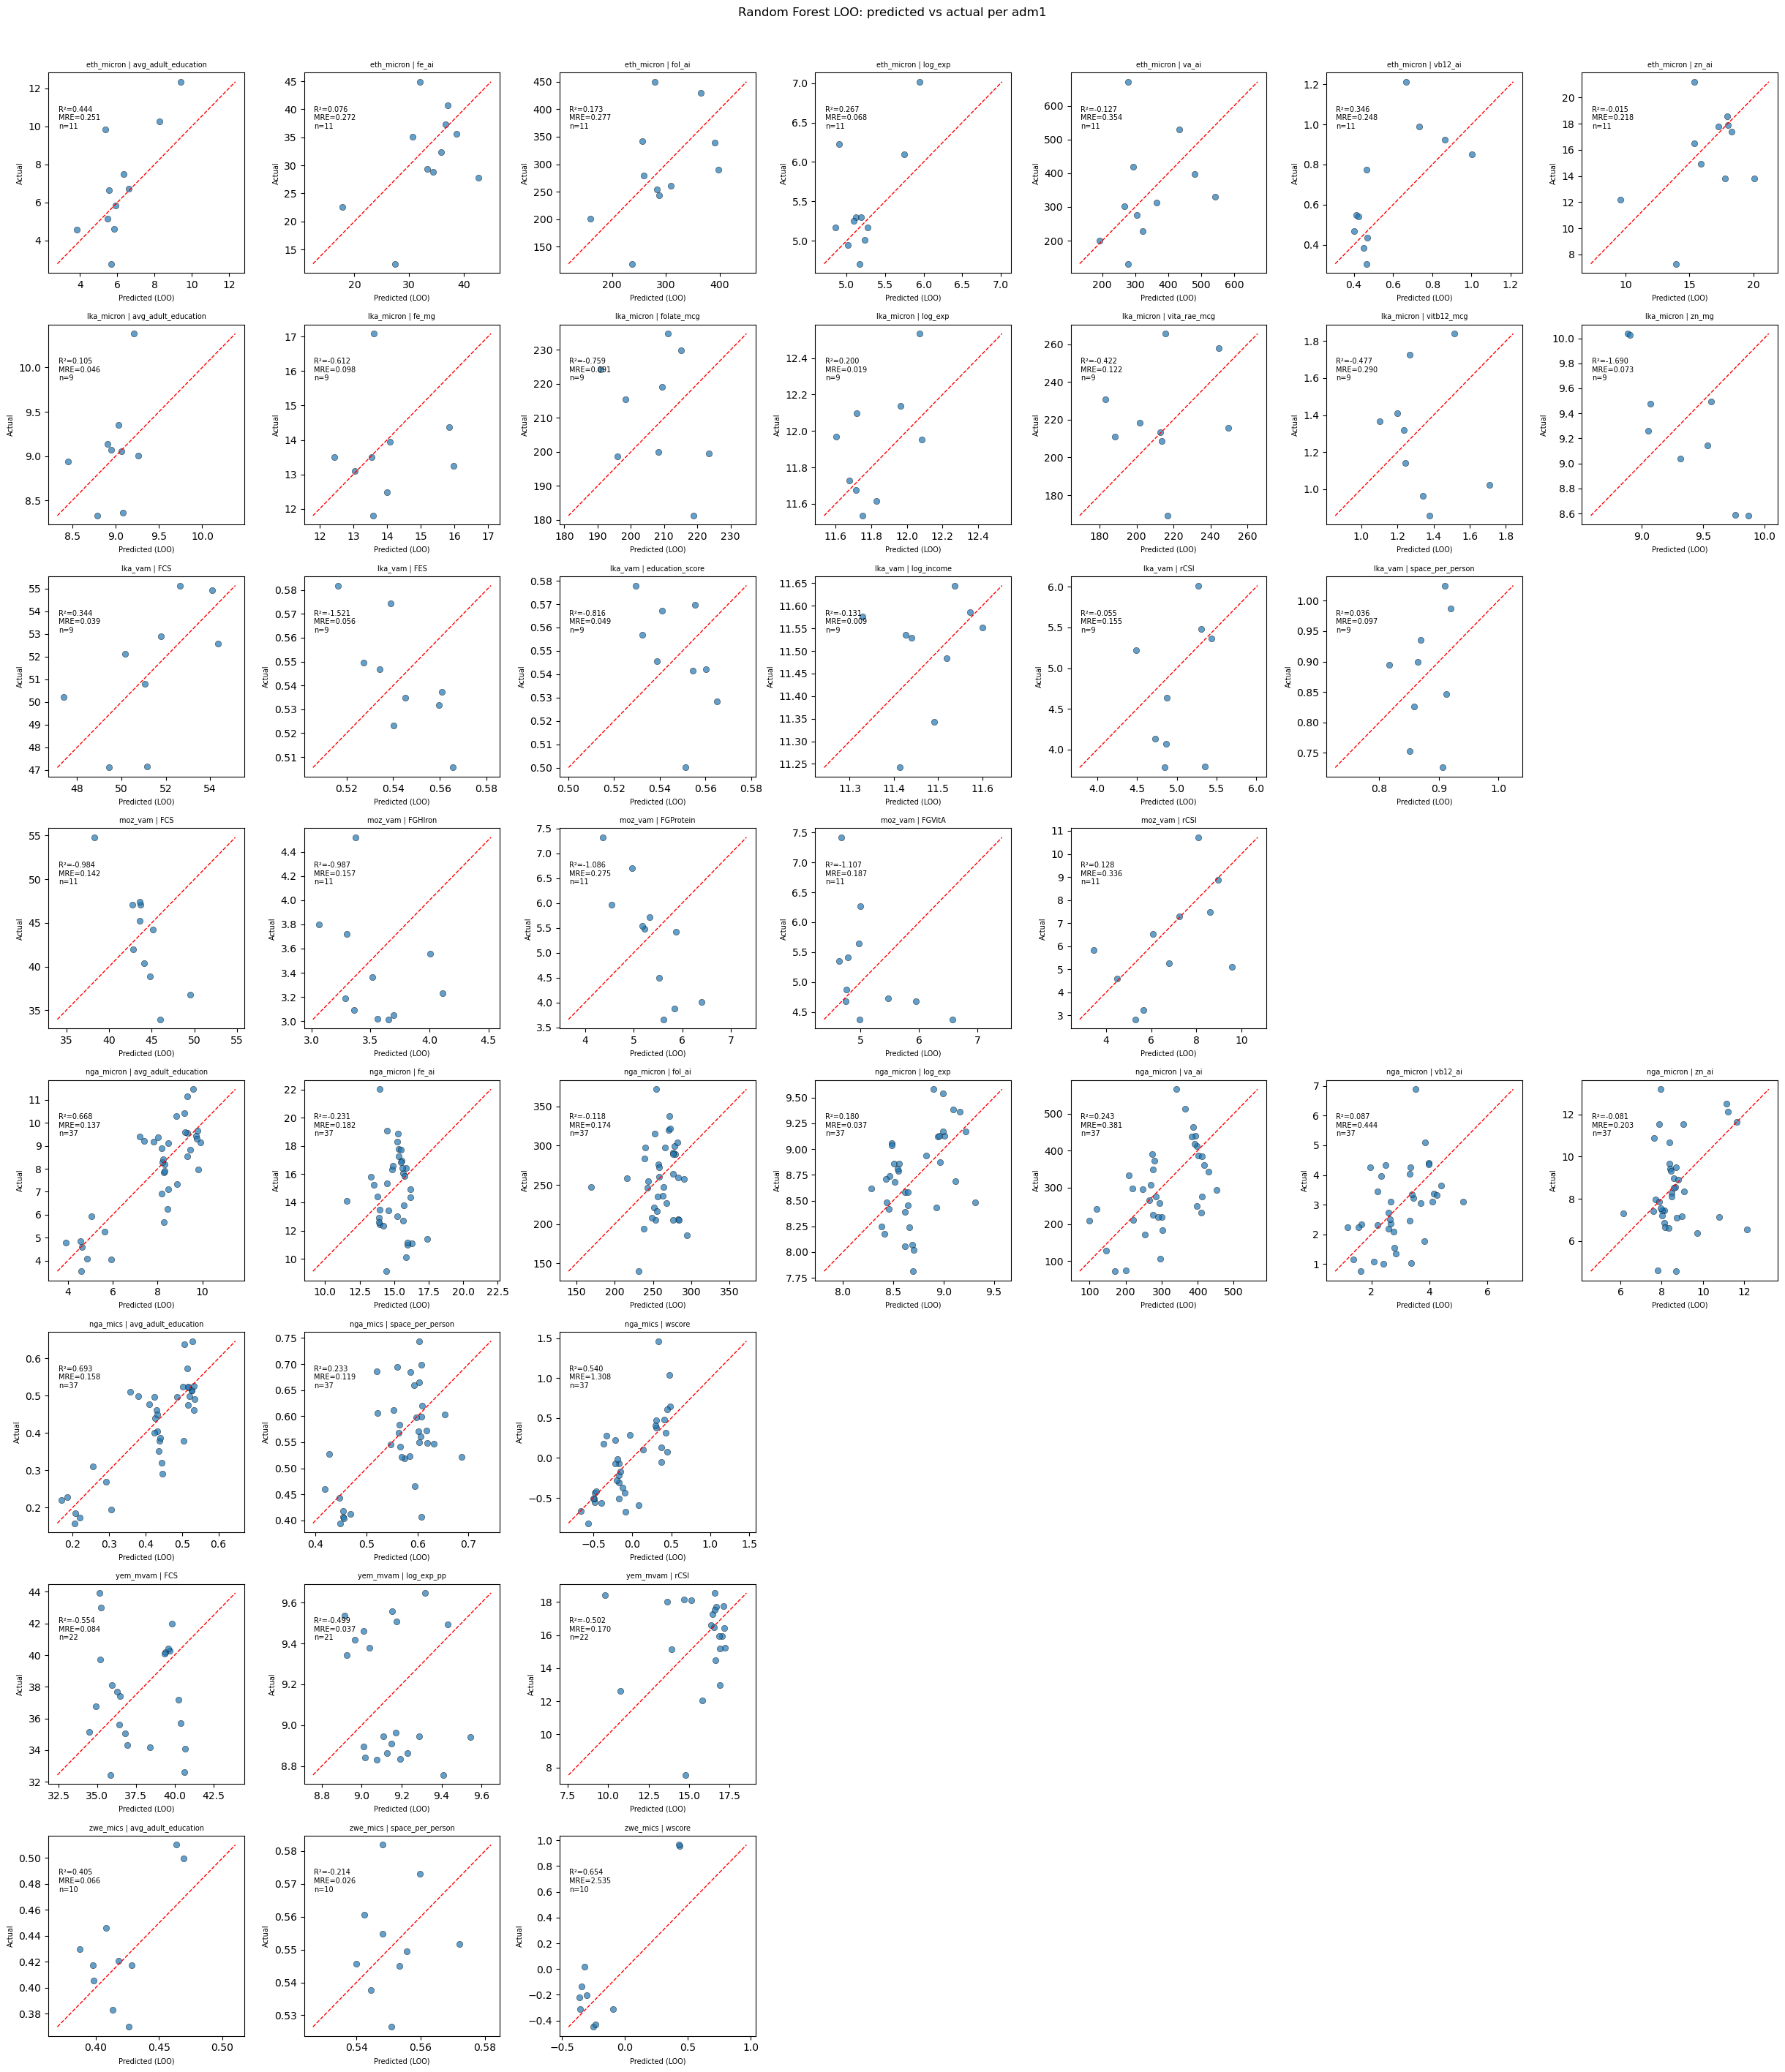

In [45]:
import matplotlib.pyplot as plt
import numpy as np

experiments = list(context_cols_by_experiment.keys())
max_targets = max(
    len(results_df[results_df["experiment_id"] == exp]["target"].unique())
    for exp in experiments
)

n_rows = len(experiments)
n_cols = max_targets

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows), squeeze=False)

for i, experiment_id in enumerate(experiments):
    exp_results = results_df[results_df["experiment_id"] == experiment_id].reset_index(drop=True)
    targets_for_exp = exp_results["target"].tolist()

    for j in range(n_cols):
        ax = axes[i][j]

        if j >= len(targets_for_exp):
            ax.set_visible(False)
            continue

        target_name = targets_for_exp[j]
        row = exp_results[exp_results["target"] == target_name].iloc[0]

        preds = loo_pred_df[
            (loo_pred_df["experiment_id"] == experiment_id) &
            (loo_pred_df["target"] == target_name)
        ]

        y_true = preds["y_true"].values
        y_pred = preds["y_pred"].values

        ax.scatter(y_pred, y_true, alpha=0.7, edgecolors="k", linewidths=0.4)

        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", linewidth=1)

        ax.set_title(f"{experiment_id} | {target_name}", fontsize=7)
        ax.set_xlabel("Predicted (LOO)", fontsize=7)
        ax.set_ylabel("Actual", fontsize=7)
        ax.annotate(
            f"R²={row['r2']:.3f}\nMRE={row['mre']:.3f}\nn={row['n_adm1']}",
            xy=(0.05, 0.72), xycoords="axes fraction", fontsize=7
        )

plt.suptitle("Random Forest LOO: predicted vs actual per adm1", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/rf_loo_grid.png", dpi=150, bbox_inches="tight")
plt.show()

eth_micron / avg_adult_education: R²=-0.830  RMSE=3.683  MAE=2.473  (n=11)
eth_micron / fe_ai: R²=-2.407  RMSE=15.716  MAE=11.032  (n=11)
eth_micron / fol_ai: R²=-5.820  RMSE=237.996  MAE=139.269  (n=11)
eth_micron / log_exp: R²=0.522  RMSE=0.454  MAE=0.365  (n=11)
eth_micron / va_ai: R²=-3.367  RMSE=306.978  MAE=191.457  (n=11)
eth_micron / vb12_ai: R²=-0.400  RMSE=0.328  MAE=0.295  (n=11)
eth_micron / zn_ai: R²=-2.132  RMSE=6.348  MAE=4.636  (n=11)
lka_micron / avg_adult_education: R²=0.649  RMSE=0.335  MAE=0.276  (n=9)
lka_micron / fe_mg: R²=-0.366  RMSE=1.641  MAE=1.155  (n=9)
lka_micron / folate_mcg: R²=-0.102  RMSE=17.383  MAE=14.749  (n=9)
lka_micron / log_exp: R²=0.501  RMSE=0.210  MAE=0.177  (n=9)
lka_micron / vita_rae_mcg: R²=0.135  RMSE=24.940  MAE=18.315  (n=9)
lka_micron / vitb12_mcg: R²=-0.462  RMSE=0.383  MAE=0.327  (n=9)
lka_micron / zn_mg: R²=-0.433  RMSE=0.599  MAE=0.518  (n=9)
lka_vam / FCS: R²=0.151  RMSE=2.548  MAE=2.127  (n=9)
lka_vam / FES: R²=-0.188  RMSE=0.025 

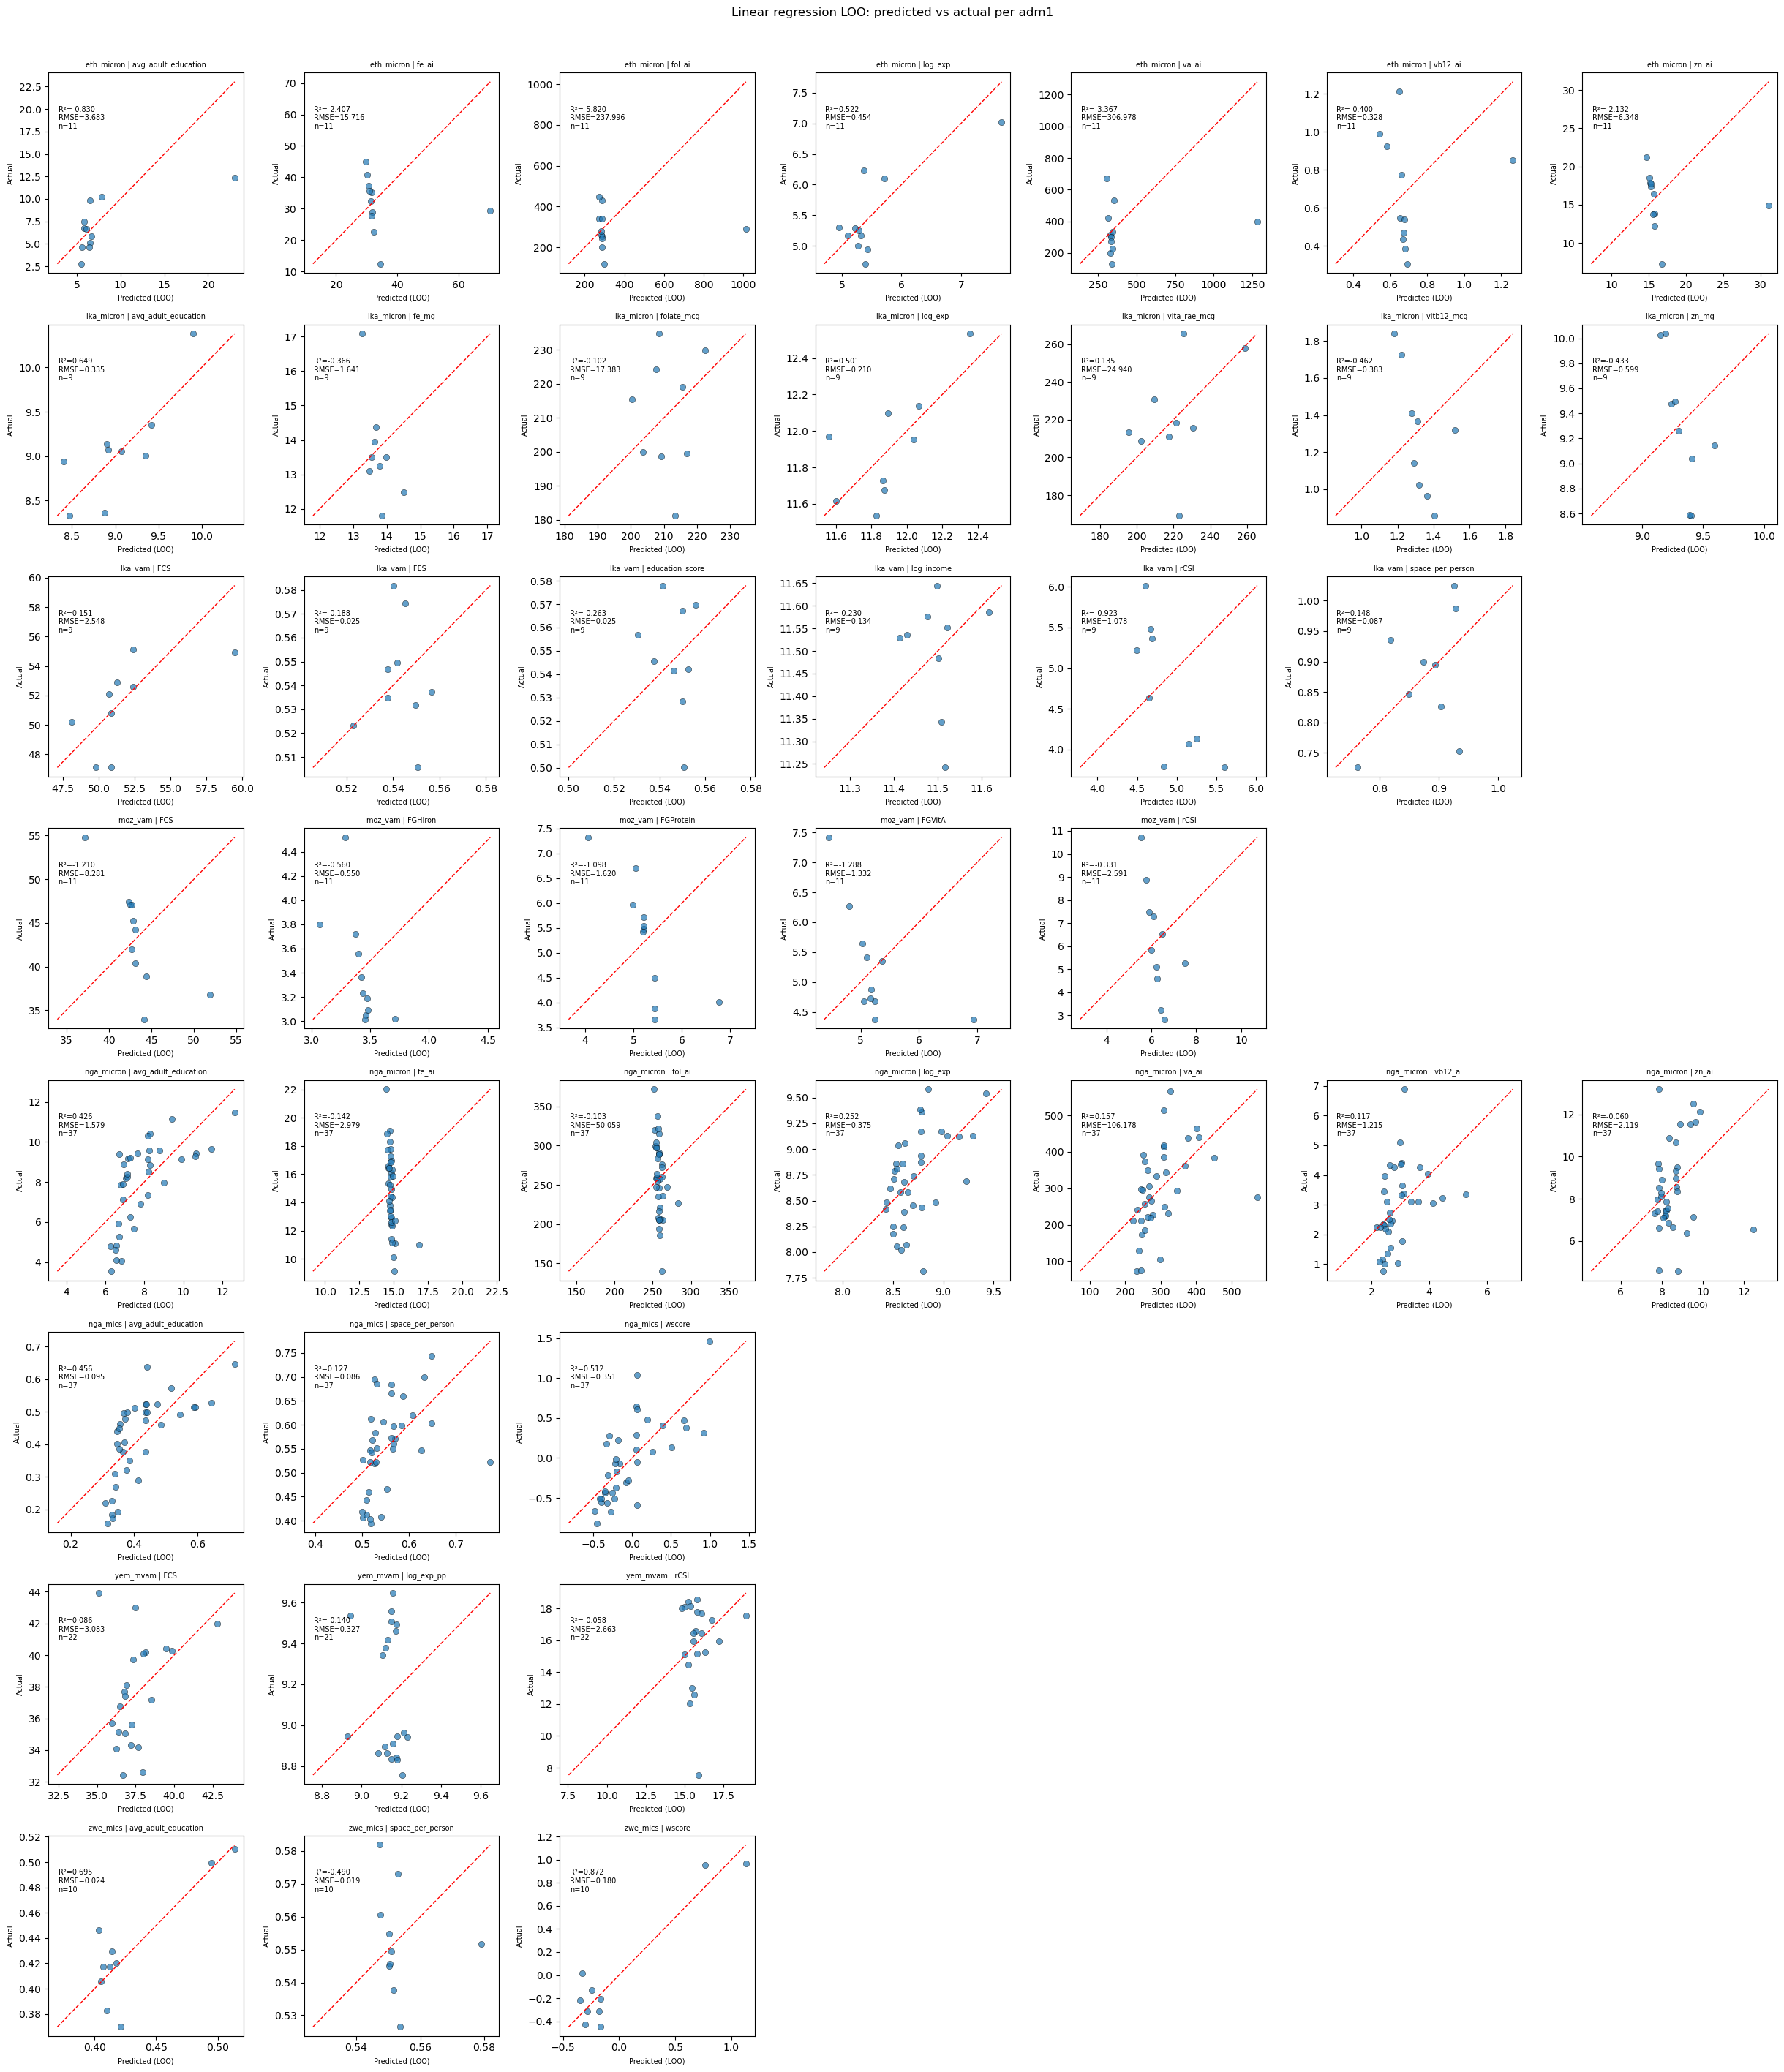

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

LOG_PATH = "/data/shared/fsibilla/clean_code/Q1/R2/regression_log_linear_loo.txt"

linear_results = []
linear_loo_pred = []

with open(LOG_PATH, "w") as log:
    def log_print(*args, **kwargs):
        msg = " ".join(str(a) for a in args)
        print(msg, **kwargs)
        log.write(msg + "\n")
        log.flush()

    for experiment_id, context_cols in context_cols_by_experiment.items():
        exp_df = metrics_avg_over_seeds[metrics_avg_over_seeds["experiment_id"] == experiment_id].copy()

        context_cols_present = [c for c in context_cols if c in exp_df.columns]
        if not context_cols_present:
            log_print(f"SKIP {experiment_id}: no context columns found")
            continue

        for target_name in exp_df["target"].unique():
            target_df = exp_df[exp_df["target"] == target_name].copy()

            cols_needed = context_cols_present + ["target_value"]
            target_df = target_df.dropna(subset=cols_needed)
            target_df = target_df[np.isfinite(target_df[cols_needed]).all(axis=1)].reset_index(drop=True)

            if len(target_df) < len(context_cols_present) + 1:
                log_print(f"SKIP {experiment_id} / {target_name}: not enough rows ({len(target_df)})")
                continue

            X = target_df[context_cols_present].values
            y = target_df["target_value"].values

            # --- LOO cross-validation ---
            loo = LeaveOneOut()
            y_true_loo, y_pred_loo, adm1_loo = [], [], []

            for train_idx, test_idx in loo.split(X):
                pipe = Pipeline([
                    ("scaler", StandardScaler()),
                    ("model", LinearRegression()),
                ])
                pipe.fit(X[train_idx], y[train_idx])
                y_true_loo.append(y[test_idx[0]])
                y_pred_loo.append(pipe.predict(X[test_idx])[0])
                adm1_loo.append(target_df.loc[test_idx[0], "adm1_name"])

            y_true_loo = np.array(y_true_loo)
            y_pred_loo = np.array(y_pred_loo)

            r2   = r2_score(y_true_loo, y_pred_loo)
            rmse = root_mean_squared_error(y_true_loo, y_pred_loo)
            mae  = mean_absolute_error(y_true_loo, y_pred_loo)

            log_print(f"{experiment_id} / {target_name}: R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  (n={len(target_df)})")

            linear_results.append({
                "experiment_id": experiment_id,
                "target": target_name,
                "r2": r2,
                "rmse": rmse,
                "mae": mae,
                "n_adm1": len(target_df),
                "context_cols": context_cols_present,
            })

            for adm1, yt, yp in zip(adm1_loo, y_true_loo, y_pred_loo):
                linear_loo_pred.append({
                    "experiment_id": experiment_id,
                    "target": target_name,
                    "adm1_name": adm1,
                    "y_true": yt,
                    "y_pred": yp,
                    "residual": yt - yp,
                })

    linear_results_df = pd.DataFrame(linear_results)
    linear_loo_pred_df = pd.DataFrame(linear_loo_pred)
    
    log_print("\n--- Summary ---")
    log_print(linear_results_df[["experiment_id", "target", "r2", "rmse", "mae", "n_adm1"]].to_string())
    log_print(f"\nLog saved to {LOG_PATH}")

# --- plot: out-of-sample predicted vs actual, one panel per experiment x target ---
experiments = list(context_cols_by_experiment.keys())
max_targets = max(
    len(linear_results_df[linear_results_df["experiment_id"] == exp]["target"].unique())
    for exp in experiments
)

n_rows = len(experiments)
n_cols = max_targets

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows), squeeze=False)

for i, experiment_id in enumerate(experiments):
    exp_results = linear_results_df[linear_results_df["experiment_id"] == experiment_id].reset_index(drop=True)
    targets_for_exp = exp_results["target"].tolist()

    for j in range(n_cols):
        ax = axes[i][j]

        if j >= len(targets_for_exp):
            ax.set_visible(False)
            continue

        target_name = targets_for_exp[j]
        row = exp_results[exp_results["target"] == target_name].iloc[0]

        preds = linear_loo_pred_df[
            (linear_loo_pred_df["experiment_id"] == experiment_id) &
            (linear_loo_pred_df["target"] == target_name)
        ]

        y_true = preds["y_true"].values
        y_pred = preds["y_pred"].values

        ax.scatter(y_pred, y_true, alpha=0.7, edgecolors="k", linewidths=0.4)

        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", linewidth=1)

        ax.set_title(f"{experiment_id} | {target_name}", fontsize=7)
        ax.set_xlabel("Predicted (LOO)", fontsize=7)
        ax.set_ylabel("Actual", fontsize=7)
        ax.annotate(
            f"R²={row['r2']:.3f}\nRMSE={row['rmse']:.3f}\nn={row['n_adm1']}",
            xy=(0.05, 0.72), xycoords="axes fraction", fontsize=7
        )

plt.suptitle("Linear regression LOO: predicted vs actual per adm1", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/linear_loo_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## R2 and improvement

   experiment_id               target        r2       mre  mean_improvement  \
0     eth_micron  avg_adult_education  0.443777  0.251138          0.128465   
1     eth_micron                fe_ai  0.076465  0.271973          0.121706   
2     eth_micron               fol_ai  0.172548  0.276508          0.196815   
3     eth_micron              log_exp  0.267261  0.067678          0.168284   
4     eth_micron                va_ai -0.127481  0.353587          0.166070   
5     eth_micron              vb12_ai  0.346114  0.247738          0.118997   
6     eth_micron                zn_ai -0.015063  0.217840          0.149815   
7     lka_micron  avg_adult_education  0.105353  0.045664          0.154896   
8     lka_micron                fe_mg -0.612040  0.098334          0.131104   
9     lka_micron           folate_mcg -0.759254  0.091197          0.108521   
10    lka_micron              log_exp  0.200444  0.018760          0.173042   
11    lka_micron         vita_rae_mcg -0.422023  0.1

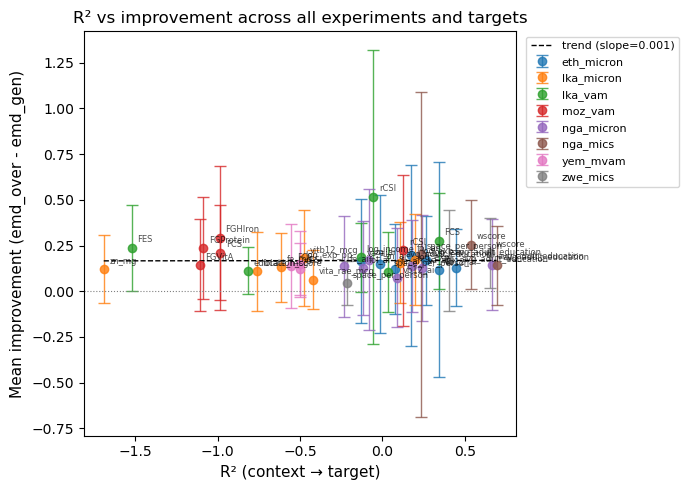

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# compute mean improvement and std per experiment x target (over adm1s, already averaged over seeds)
# but we need std over seeds, so go back to metrics_with_context (before seed averaging)
improvement_stats = (
    metrics_with_context
    .assign(improvement=lambda df: df["emd_over"] - df["emd_gen"])
    .groupby(["experiment_id", "target"], dropna=False)
    .agg(
        mean_improvement=("improvement", "mean"),
        std_improvement=("improvement", "std"),
    )
    .reset_index()
)

# merge with results_df on experiment_id + target
plot_df = results_df[["experiment_id", "target", "r2", "mre"]].merge(
    improvement_stats,
    on=["experiment_id", "target"],
    how="inner",
)

print(plot_df)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

# one color per experiment
experiments = plot_df["experiment_id"].unique()
cmap = plt.get_cmap("tab10")
colors = {exp: cmap(k) for k, exp in enumerate(experiments)}

for exp_id, group in plot_df.groupby("experiment_id"):
    ax.errorbar(
        group["r2"],
        group["mean_improvement"],
        yerr=group["std_improvement"],
        fmt="o",
        color=colors[exp_id],
        label=exp_id,
        capsize=4,
        linewidth=1,
        markersize=6,
        alpha=0.8,
    )
    # annotate each point with target name
    for _, r in group.iterrows():
        ax.annotate(
            r["target"],
            xy=(r["r2"], r["mean_improvement"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=6,
            alpha=0.7,
        )

# overall regression line across all points
from numpy.polynomial.polynomial import polyfit
x = plot_df["r2"].values
y = plot_df["mean_improvement"].values
if len(x) > 1:
    b, m = polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, b + m * x_line, "k--", linewidth=1, label=f"trend (slope={m:.3f})")

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("R² (context → target)", fontsize=11)
ax.set_ylabel("Mean improvement (emd_over - emd_gen)", fontsize=11)
ax.set_title("R² vs improvement across all experiments and targets", fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/r2_vs_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

   experiment_id               target       mre  mean_improvement  \
0     eth_micron  avg_adult_education  0.251138          0.128465   
1     eth_micron                fe_ai  0.271973          0.121706   
2     eth_micron               fol_ai  0.276508          0.196815   
3     eth_micron              log_exp  0.067678          0.168284   
4     eth_micron                va_ai  0.353587          0.166070   
5     eth_micron              vb12_ai  0.247738          0.118997   
6     eth_micron                zn_ai  0.217840          0.149815   
7     lka_micron  avg_adult_education  0.045664          0.154896   
8     lka_micron                fe_mg  0.098334          0.131104   
9     lka_micron           folate_mcg  0.091197          0.108521   
10    lka_micron              log_exp  0.018760          0.173042   
11    lka_micron         vita_rae_mcg  0.121861          0.064282   
12    lka_micron           vitb12_mcg  0.289592          0.181099   
13    lka_micron                zn

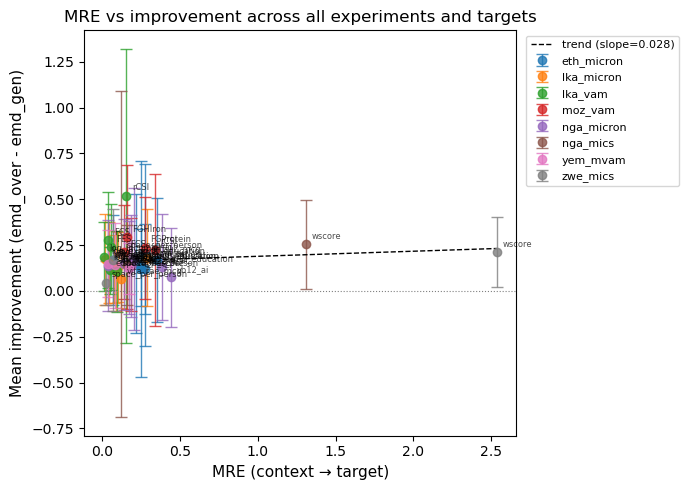

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.polynomial import polyfit

improvement_stats = (
    metrics_with_context
    .assign(improvement=lambda df: df["emd_over"] - df["emd_gen"])
    .groupby(["experiment_id", "target"], dropna=False)
    .agg(
        mean_improvement=("improvement", "mean"),
        std_improvement=("improvement", "std"),
    )
    .reset_index()
)

plot_df = results_df[["experiment_id", "target", "mre"]].merge(
    improvement_stats,
    on=["experiment_id", "target"],
    how="inner",
)

print(plot_df)

fig, ax = plt.subplots(figsize=(7, 5))

experiments = plot_df["experiment_id"].unique()
cmap = plt.get_cmap("tab10")
colors = {exp: cmap(k) for k, exp in enumerate(experiments)}

for exp_id, group in plot_df.groupby("experiment_id"):
    ax.errorbar(
        group["mre"],
        group["mean_improvement"],
        yerr=group["std_improvement"],
        fmt="o",
        color=colors[exp_id],
        label=exp_id,
        capsize=4,
        linewidth=1,
        markersize=6,
        alpha=0.8,
    )
    for _, r in group.iterrows():
        ax.annotate(
            r["target"],
            xy=(r["mre"], r["mean_improvement"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=6,
            alpha=0.7,
        )

x = plot_df["mre"].values
y = plot_df["mean_improvement"].values
if len(x) > 1:
    b, m = polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, b + m * x_line, "k--", linewidth=1, label=f"trend (slope={m:.3f})")

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("MRE (context → target)", fontsize=11)
ax.set_ylabel("Mean improvement (emd_over - emd_gen)", fontsize=11)
ax.set_title("MRE vs improvement across all experiments and targets", fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/mre_vs_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
# Cell - correlate R², RMSE, MAE with mean improvement

from scipy import stats

metrics_to_correlate = ["r2", "rmse", "mae"]

print(f"{'Metric':<8}  {'Pearson r':>10}  {'p-value':>10}  {'Spearman r':>12}  {'p-value':>10}  n")
print("-" * 65)

for metric in metrics_to_correlate:
    valid = plot_df[["mean_improvement", metric]].dropna()
    x = valid[metric].values
    y = valid["mean_improvement"].values

    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)

    print(f"{metric:<8}  {pr:>10.3f}  {pp:>10.4f}  {sr:>12.3f}  {sp:>10.4f}  {len(valid)}")

Metric     Pearson r     p-value    Spearman r     p-value  n
-----------------------------------------------------------------
r2             0.008      0.9626         0.106      0.5105  41


KeyError: "['rmse'] not in index"

Metric     Pearson r     p-value    Spearman r     p-value  n
-----------------------------------------------------------------
r2             0.008      0.9626         0.106      0.5105  41
rmse          -0.086      0.5909        -0.107      0.5042  41
mae           -0.090      0.5758        -0.105      0.5154  41


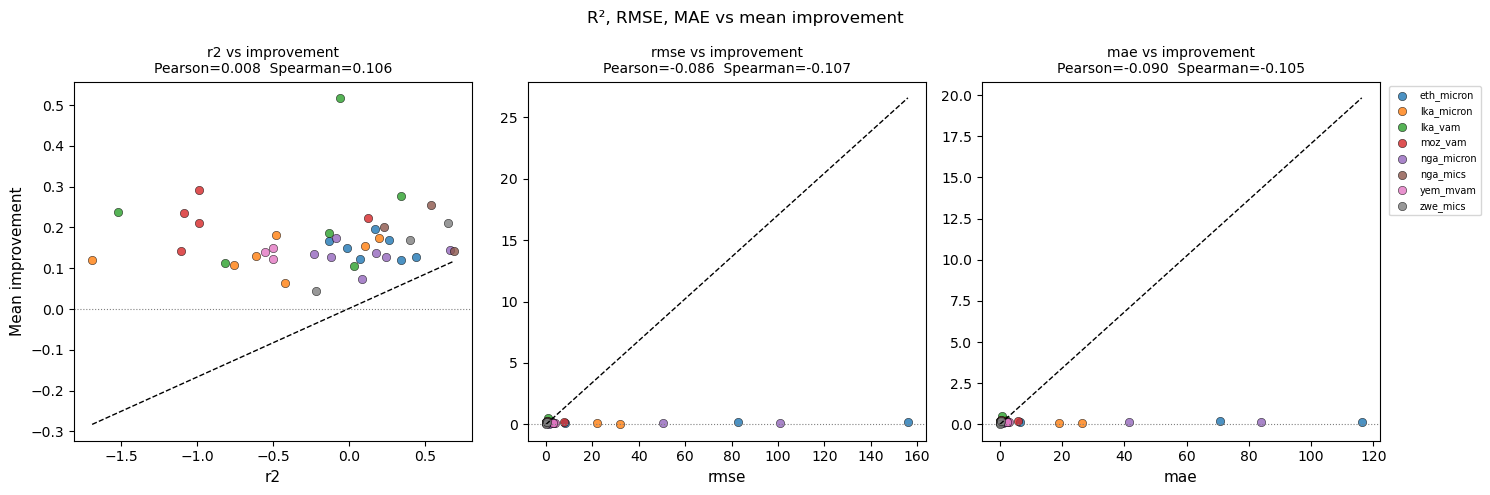

In [37]:
# Cell - correlate R², RMSE, MAE with mean improvement and plot

from scipy import stats
import matplotlib.pyplot as plt

improvement_stats = (
    metrics_with_context
    .assign(improvement=lambda df: df["emd_over"] - df["emd_gen"])
    .groupby(["experiment_id", "target"], dropna=False)
    .agg(mean_improvement=("improvement", "mean"))
    .reset_index()
)

corr_df = results_df[["experiment_id", "target", "r2", "rmse", "mae"]].merge(
    improvement_stats, on=["experiment_id", "target"], how="inner"
)

print(f"{'Metric':<8}  {'Pearson r':>10}  {'p-value':>10}  {'Spearman r':>12}  {'p-value':>10}  n")
print("-" * 65)

for metric in ["r2", "rmse", "mae"]:
    valid = corr_df[["mean_improvement", metric]].dropna()
    pr, pp = stats.pearsonr(valid[metric], valid["mean_improvement"])
    sr, sp = stats.spearmanr(valid[metric], valid["mean_improvement"])
    print(f"{metric:<8}  {pr:>10.3f}  {pp:>10.4f}  {sr:>12.3f}  {sp:>10.4f}  {len(valid)}")

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

experiments = corr_df["experiment_id"].unique()
cmap = plt.get_cmap("tab10")
colors = {exp: cmap(k) for k, exp in enumerate(experiments)}

for ax, metric in zip(axes, ["r2", "rmse", "mae"]):
    valid = corr_df[["experiment_id", "target", "mean_improvement", metric]].dropna()

    for exp_id, group in valid.groupby("experiment_id"):
        ax.scatter(group[metric], group["mean_improvement"],
                   color=colors[exp_id], label=exp_id, alpha=0.8, edgecolors="k", linewidths=0.4)

    # trend line
    x, y = valid[metric].values, valid["mean_improvement"].values
    if len(x) > 1:
        b, m = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m * x_line + b, "k--", linewidth=1)

    pr, _ = stats.pearsonr(x, y)
    sr, _ = stats.spearmanr(x, y)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_ylabel("Mean improvement" if metric == "r2" else "", fontsize=11)
    ax.set_title(f"{metric} vs improvement\nPearson={pr:.3f}  Spearman={sr:.3f}", fontsize=10)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")

axes[-1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.suptitle("R², RMSE, MAE vs mean improvement", fontsize=12)
plt.tight_layout()
plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/metrics_vs_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

  experiment_id   mean_r2    std_r2  mean_improvement  std_improvement
0    eth_micron  0.878640  0.026108          0.150022         0.357205
1    lka_micron  0.757941  0.122221          0.133169         0.212428
2       lka_vam  0.788291  0.105875          0.239368         0.306164
3       moz_vam  0.496528  0.197388          0.221370         0.319477
4    nga_micron  0.643851  0.123590          0.131598         0.282835
5      nga_mics  0.795878  0.109275          0.199076         0.449962
6      yem_mvam  0.609839  0.056725          0.137005         0.184363
7      zwe_mics  0.876159  0.076122          0.141561         0.195562


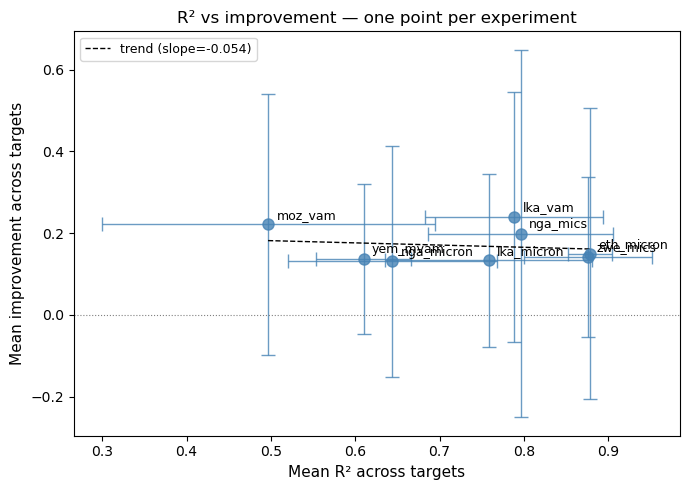

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.polynomial import polyfit

# aggregate to experiment level
exp_level = (
    plot_df
    .groupby("experiment_id")
    .agg(
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        mean_improvement=("mean_improvement", "mean"),
        std_improvement=("std_improvement", "mean"),  # mean of per-target stds
    )
    .reset_index()
)

print(exp_level)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    exp_level["mean_r2"],
    exp_level["mean_improvement"],
    xerr=exp_level["std_r2"],
    yerr=exp_level["std_improvement"],
    fmt="o",
    color="steelblue",
    capsize=5,
    linewidth=1,
    markersize=8,
    alpha=0.8,
)

for _, r in exp_level.iterrows():
    ax.annotate(
        r["experiment_id"],
        xy=(r["mean_r2"], r["mean_improvement"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
    )

# trend line
x = exp_level["mean_r2"].values
y = exp_level["mean_improvement"].values
if len(x) > 1:
    b, m = polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, b + m * x_line, "k--", linewidth=1, label=f"trend (slope={m:.3f})")

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Mean R² across targets", fontsize=11)
ax.set_ylabel("Mean improvement across targets", fontsize=11)
ax.set_title("R² vs improvement — one point per experiment", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/r2_vs_improvement_per_experiment.png", dpi=150, bbox_inches="tight")
plt.show()